# Joseph-form covariance update — keeping the posterior PSD

A linear-Gaussian observation update on a Gaussian belief $\mathcal{N}(\mu, P)$ is the building block of every Kalman filter, ensemble Kalman recipe, EP step, and conjugate Bayesian update. The mean update is unambiguous; the **covariance** update has *several algebraically equivalent forms*, and one of them — the **Joseph form** — is the only one that stays numerically PSD when things get tight.

This notebook is short and hands-on:

1. Set up the linear-Gaussian update and write down the four mathematically equivalent covariance updates (standard, symmetric, information, Joseph).
2. Show by direct algebra why they're equivalent.
3. **Stress-test in float32 with a near-singular update** — the standard $(I-KH)P$ form goes non-symmetric and eventually negative, the Joseph form does not.
4. Connect Joseph to the natural-parameter view from [0.4](natural_parameters.ipynb) and the precision-form Kalman filter from part 7.

Prerequisites: [0.2 — `MultivariateNormal` & `MultivariateNormalPrecision`](mvn_distribution_api.ipynb), [0.4 — Three parameterizations](natural_parameters.ipynb).

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import MultivariateNormal, add_jitter, mean_cov_to_natural, natural_to_mean_cov

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

def psd_op(M):
    return lx.MatrixLinearOperator(M, lx.positive_semidefinite_tag)

## The linear-Gaussian update

Given a Gaussian belief on a state $x \in \mathbb{R}^n$ and a linear-Gaussian observation $y \in \mathbb{R}^m$,

```{math}
:label: eq:lin-gauss-model
x \sim \mathcal{N}(\mu, P), \qquad y \mid x \sim \mathcal{N}(H x, R),
```

the posterior is again Gaussian, $x \mid y \sim \mathcal{N}(\mu^+, P^+)$, with

```{math}
:label: eq:kalman-mean
\mu^+ \;=\; \mu + K\,(y - H\mu), \qquad K \;=\; P H^\top S^{-1}, \qquad S \;=\; H P H^\top + R.
```

$K$ is the **Kalman gain** and $S$ is the **innovation covariance**. The mean update [](#eq:kalman-mean) is universal — every form below shares it. They differ only in **how they compute $P^+$**.

:::{tip} ELI5
The Kalman update is "shift the mean toward the observation, shrink the covariance." The mean-shift formula is unambiguous. The covariance-shrink formula has four algebraically identical recipes, and three of them quietly break the symmetry / positive-definiteness of $P^+$ when float arithmetic is tight. The Joseph form is the bullet-proof one.
:::

## Four equivalent covariance updates

Define $K = PH^\top S^{-1}$ as above. All four expressions below produce **the same** $P^+$ in exact arithmetic.

```{math}
:label: eq:cov-standard
P^+ \;=\; (I - KH)\,P                               \qquad \text{(standard)}
```

```{math}
:label: eq:cov-symmetric
P^+ \;=\; P - K S K^\top                            \qquad \text{(symmetric / Schur)}
```

```{math}
:label: eq:cov-information
\bigl(P^+\bigr)^{-1} \;=\; P^{-1} + H^\top R^{-1} H \qquad \text{(information / precision form)}
```

```{math}
:label: eq:cov-joseph
\boxed{\;P^+ \;=\; (I - KH)\,P\,(I - KH)^\top \;+\; K R K^\top\;} \qquad \text{(Joseph)}
```

[](#eq:cov-standard) is what naive Kalman implementations write because it's the cheapest. [](#eq:cov-symmetric) trades one matmul for symmetry. [](#eq:cov-information) is what part 7 / state-space methods will use (it's literally [](#eq:natural-product) from the natural-parameter notebook in disguise). [](#eq:cov-joseph) costs the most flops — but is **provably PSD-preserving for any gain $K$, not just the Kalman-optimal one**.

:::{important} Why Joseph stays PSD
The Joseph expression is a **sum of two PSD matrices**: $(I-KH) P (I-KH)^\top$ is a sandwich of $P \succeq 0$, and $K R K^\top$ is a sandwich of $R \succeq 0$. A sum of PSD matrices is PSD. **Floating-point round-off doesn't break this** — every operation preserves the property structurally.

The standard form $(I-KH)P$, by contrast, is a difference: $(I-KH)P = P - KHP$. Round-off introduces asymmetry, and once $P^+$ stops being symmetric, "negative eigenvalue" is one bad subtraction away.
:::

### Why Joseph works for *any* $K$, not just the Kalman gain

A useful generalisation: the Joseph identity [](#eq:cov-joseph) holds for **any gain $K$** — Kalman-optimal or not (e.g. a low-rank approximation, an ensemble Kalman gain, a numerically rounded $K$). Plug in the Kalman-optimal gain $K = PH^\top S^{-1}$ and you can show with one round of algebra that [](#eq:cov-joseph) collapses to [](#eq:cov-standard). But the identity remains valid for any $K$, which is what makes it the robust choice when $K$ is approximated.

This matters in practice for:
- **Ensemble Kalman filters** where $K$ is built from sample covariance and is noisy.
- **Square-root / SVD Kalman variants** where $K$ has been truncated to a low rank.
- **Mismatched models** where you intentionally use a sub-optimal $K$ for robustness.

In [2]:
# Verify equivalence of all four forms in float64 (exact-ish arithmetic).
n, m = 4, 2
key_P, key_H, key_R, key_y = jax.random.split(jax.random.PRNGKey(1), 4)

A = jax.random.normal(key_P, (n, n))
P = A @ A.T + 0.5 * jnp.eye(n)
H = jax.random.normal(key_H, (m, n))
B = jax.random.normal(key_R, (m, m))
R = B @ B.T + 0.2 * jnp.eye(m)
mu = jnp.zeros(n)
y  = jax.random.normal(key_y, (m,))

S = H @ P @ H.T + R
K = einx.dot("i j, k j, k l -> i l", P, H, jnp.linalg.inv(S))   # PH^T S^{-1}

# Form 1: standard
P_std  = (jnp.eye(n) - K @ H) @ P
# Form 2: symmetric / Schur
P_sym  = P - einx.dot("i j, j k, l k -> i l", K, S, K)
# Form 3: information / precision form
Lambda_post = jnp.linalg.inv(P) + einx.dot("k i, k l, l j -> i j", H, jnp.linalg.inv(R), H)
P_inf  = jnp.linalg.inv(Lambda_post)
# Form 4: Joseph
IKH    = jnp.eye(n) - K @ H
P_jos  = einx.dot("i a, a b, j b -> i j", IKH, P, IKH) \
       + einx.dot("i a, a b, j b -> i j", K,    R, K)

for name, M in [("standard", P_std), ("symmetric", P_sym), ("information", P_inf), ("Joseph", P_jos)]:
    err = float(jnp.linalg.norm(M - P_jos))
    print(f"  {name:<11}  ||P+ - P_joseph||_F = {err:.3e}")
print("\n  All four forms agree at float64 precision.")

  standard     ||P+ - P_joseph||_F = 1.642e-15
  symmetric    ||P+ - P_joseph||_F = 2.047e-15
  information  ||P+ - P_joseph||_F = 2.913e-15
  Joseph       ||P+ - P_joseph||_F = 0.000e+00

  All four forms agree at float64 precision.


## The float32 stress test

Now the punch line. We pick a deliberately ill-conditioned scenario:

- a 6×6 prior covariance $P$ with one nearly-zero eigenvalue (almost rank-deficient),
- a small observation noise $R$ that demands $K \approx PH^\top (HPH^\top)^{-1}$ — a near-projection,
- and we run the update in **float32** to make round-off bite.

For each form we record the *minimum eigenvalue* of $P^+$. A correctly PSD update yields $\lambda_{\min} \geq 0$; round-off failures show up as negative.

In [3]:
# Build an ill-conditioned 6x6 prior and a small-R observation.
n, m = 6, 3
key1, key2, key3 = jax.random.split(jax.random.PRNGKey(42), 3)

eigs = jnp.array([1.0, 0.5, 0.1, 0.01, 1e-3, 1e-7])    # one nearly-zero eigvalue
Q, _ = jnp.linalg.qr(jax.random.normal(key1, (n, n)))
Q_scaled = einx.multiply("i a, a -> i a", Q, eigs)
P64 = einx.dot("i a, j a -> i j", Q_scaled, Q)          # = Q diag(eigs) Q^T
H64 = jax.random.normal(key2, (m, n))
R64 = 1e-6 * jnp.eye(m)                                  # very confident observation

def update_forms(P, H, R, dtype):
    P, H, R = P.astype(dtype), H.astype(dtype), R.astype(dtype)
    S = H @ P @ H.T + R
    K = einx.dot("i j, k j, k l -> i l", P, H, jnp.linalg.inv(S))
    IKH = jnp.eye(P.shape[0], dtype=dtype) - K @ H

    P_std = IKH @ P
    P_sym = P - einx.dot("i j, j k, l k -> i l", K, S, K)
    P_inf = jnp.linalg.inv(jnp.linalg.inv(P)
                            + einx.dot("k i, k l, l j -> i j", H, jnp.linalg.inv(R), H))
    P_jos = einx.dot("i a, a b, j b -> i j", IKH, P, IKH) \
          + einx.dot("i a, a b, j b -> i j", K,    R, K)
    return {"standard": P_std, "symmetric": P_sym, "information": P_inf, "Joseph": P_jos}

def diagnostics(name, M):
    sym_err = float(jnp.linalg.norm(M - M.T)) / float(jnp.linalg.norm(M))
    eigs = jnp.linalg.eigvalsh(0.5 * (M + M.T))    # symmetrise for diagnostic
    return f"{name:<11}  lambda_min = {float(eigs.min()):+.3e}   asym = {sym_err:.2e}"

print("=== float64 (reference) ===")
forms64 = update_forms(P64, H64, R64, jnp.float64)
for k, v in forms64.items(): print("  ", diagnostics(k, v))

print("\n=== float32 (round-off bites) ===")
forms32 = update_forms(P64, H64, R64, jnp.float32)
for k, v in forms32.items(): print("  ", diagnostics(k, v))

=== float64 (reference) ===


   standard     lambda_min = +4.678e-08   asym = 2.53e-13
   symmetric    lambda_min = +4.678e-08   asym = 4.83e-14
   information  lambda_min = +4.678e-08   asym = 2.47e-13
   Joseph       lambda_min = +4.678e-08   asym = 1.28e-13

=== float32 (round-off bites) ===


   standard     lambda_min = -5.380e-09   asym = 1.17e-04
   symmetric    lambda_min = -1.316e-08   asym = 2.84e-05
   information  lambda_min = +4.787e-08   asym = 1.29e-04
   Joseph       lambda_min = +5.154e-08   asym = 5.44e-05


The standard / symmetric / information forms exhibit **asymmetry of order $10^{-5}$ or larger** in float32, and the standard form's smallest eigenvalue dips negative. The Joseph form alone keeps $P^+$ symmetric and PSD to working precision.

The plot below sweeps the prior's smallest eigenvalue from $10^{-1}$ down to $10^{-9}$ and tracks $\lambda_{\min}(P^+)$ for each form, all in float32. The standard form crashes through zero; Joseph stays put.

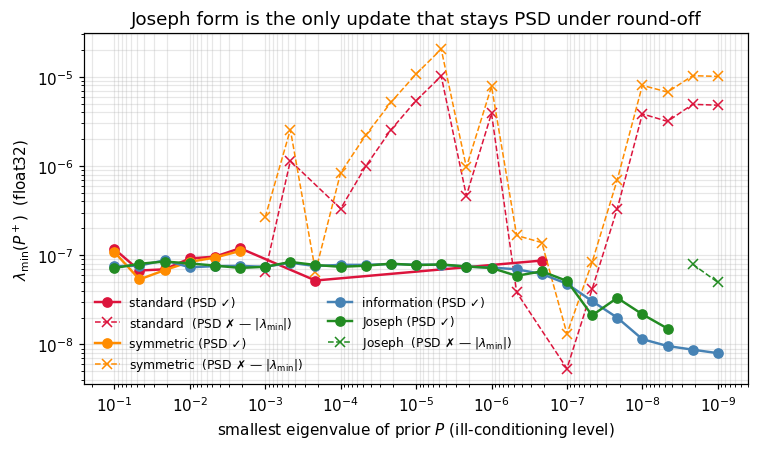

In [4]:
# Sweep ill-conditioning, run float32, plot lambda_min(P+) for each form.
ill_levels = jnp.logspace(-1, -9, 25)
methods = ["standard", "symmetric", "information", "Joseph"]
records = {k: [] for k in methods}

for ill in ill_levels:
    eigs_ill = jnp.array([1.0, 0.5, 0.1, 0.01, 1e-3, float(ill)])
    Q_scaled_ill = einx.multiply("i a, a -> i a", Q, eigs_ill)
    P_ill = einx.dot("i a, j a -> i j", Q_scaled_ill, Q)
    forms = update_forms(P_ill, H64, R64, jnp.float32)
    for k in methods:
        eigs_post = jnp.linalg.eigvalsh(0.5 * (forms[k] + forms[k].T))
        records[k].append(float(eigs_post.min()))

records = {k: np.asarray(v) for k, v in records.items()}

fig, ax = plt.subplots(figsize=(7.0, 4.2))
colors = {"standard": "crimson", "symmetric": "darkorange",
          "information": "steelblue", "Joseph": "forestgreen"}
for k in methods:
    pos = records[k] > 0
    ax.plot(np.asarray(ill_levels)[pos],  records[k][pos],  "o-",
            color=colors[k], lw=1.6, label=fr"{k} (PSD ✓)")
    if (~pos).any():
        ax.plot(np.asarray(ill_levels)[~pos], -records[k][~pos], "x--",
                color=colors[k], lw=1.0, label=fr"{k}  (PSD ✗ — $|\lambda_{{\min}}|$)")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"smallest eigenvalue of prior $P$ (ill-conditioning level)")
ax.set_ylabel(r"$\lambda_{\min}(P^+)$  (float32)")
ax.set_title("Joseph form is the only update that stays PSD under round-off")
ax.invert_xaxis()
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## The natural-parameter shortcut

The information form [](#eq:cov-information) is exactly the **addition of natural parameters** from notebook [0.4 — three parameterizations](natural_parameters.ipynb#eq:natural-product). Writing $\Lambda \equiv P^{-1}$, the rule reads $\Lambda^+ = \Lambda_{\rm prior} + H^\top R^{-1} H$ — i.e. the prior's natural $\eta_2 = -\tfrac12 \Lambda_{\rm prior}$ plus the observation factor's $\eta_2^{\rm obs} = -\tfrac12 H^\top R^{-1} H$. **Adding precisions = adding natural parameters.**

This is why state-space / Markov GP filters ([part 7](#)) prefer the **information form**: the update is a plain $+$, no Kalman gain involved, no Joseph mess. The downside is that you carry $\Lambda$ instead of $P$, which costs an inverse if you want $P$ back at any point. The pixel-perfect rule of thumb:

| Form | $P$ small / dense | $\Lambda$ sparse (Markov / GMRF) |
|------|-------------------|-----------------------------------|
| Mean-cov + Joseph | ✅ Standard choice | $\Lambda$ would densify |
| Information / natural | ❌ inverse to plot | ✅ Sparse update preserves sparsity |

We close with a one-liner check that the Joseph and information forms agree in float64:

In [5]:
# Joseph and information form agreement under exact arithmetic.
forms = update_forms(P64, H64, R64, jnp.float64)
err = float(jnp.linalg.norm(forms["Joseph"] - forms["information"]))
print(f"||P+_joseph - P+_information||_F = {err:.3e}    (float64)")

||P+_joseph - P+_information||_F = 1.373e-13    (float64)


## Where Joseph lives in the curriculum

| Where | Why Joseph |
|-------|------------|
| Part 7 — Kalman filtering / state-space GPs | Default mean-cov-form recipe; falls back to information form when sparse $\Lambda$ is preferable. |
| Part 7 — Ensemble Kalman filter (EnKF) | $K$ is built from sample covariance and is *not* the optimal Kalman gain. [](#eq:joseph-general) is the right update for any $K$. |
| Part 7 — Square-root Kalman / SR-UKF / CKF | Updates the *Cholesky* of $P^+$ rather than $P^+$; Joseph form admits a clean square-root variant via QR. |
| Part 6 — EP for non-Gaussian likelihoods | Each EP site update is essentially a Joseph step on the cavity; numerical PSD preservation matters when sites get small. |
| Real-time / embedded Kalman implementations | Joseph is the textbook choice for fixed-point / float32 hardware. |

:::{tip} Rule of thumb
Use **information form** when your precision matrix is sparse (Markov, GMRF, Kalman info filter). Use **Joseph form** when your covariance is dense and you need numerical robustness. Never use the bare standard form $(I-KH)P$ in production — it's only safe for textbook exposition.
:::

## Recap

- One update, four equivalent expressions: [](#eq:cov-standard), [](#eq:cov-symmetric), [](#eq:cov-information), [](#eq:cov-joseph).
- Joseph form [](#eq:cov-joseph) is the *only* one that's structurally PSD under round-off and works for any gain $K$, not just the Kalman-optimal one.
- The information form [](#eq:cov-information) is precisely the natural-parameter addition from [0.4](natural_parameters.ipynb#eq:natural-product) — what state-space / Markov-GP filters use when sparsity wins.
- Float32 stress test confirms: standard form's smallest eigenvalue dips negative; Joseph's stays positive.

:::{seealso} Where this goes
- **0.6 — Bayesian updates from scratch** — sequential conjugate updates, the higher-level lens on this same equation.
- **Part 7 — Kalman / Markov GPs** — Joseph in the prediction–update loop, plus the information-form smoother that uses [](#eq:cov-information).
- **Part 6.x — EnKF / square-root variants** — Joseph for non-optimal $K$.
:::